# Borssele 1 & 2, Project Finance Debt Model

Lender's perspective, 2016. Companion to the equity DCF model (Project 1) and validated against
the Excel debt model (Project 2).

**Structure**
1. Assumptions
2. Tax functions (CIT brackets, ATAD)
3. Debt sizing, closed-form, lowest of three tests
4. Validation against Excel
5. Deterministic cash flow and waterfall
6. Validating the stress test scenarios
7. Degradation scenarios
8. Ornstein-Uhlenbeck price process
9. Monte Carlo: covenant-breach probability
10. Sensitivity dashboard


## 1. Assumptions

In [33]:
import numpy as np
import numpy_financial as npf
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)



In [34]:
assumptions = {
    # Physical & production
    "capacity_mw": 752,
    "cf_p50": 0.50,
    "degradation": 0.000,
    "p90_uncertainty": 0.10,

    # CAPEX & decommissioning
    "capex_eib_m": 1491,
    "decom_m": 42,
    "capex_overrun_pct": 0.20,

    # OPEX
    "opex_var": 9.59,
    "opex_fix": 40_350,
    "opex_infl": 0.02,

    # Revenue / SDE+ (ex-ante lens)
    "tender": 72.70,
    "floor": 29.00,
    "subsidy_years": 15,
    "exante_price": 30.00,
    "price_shock_pct": -0.20,

    # Original financing (2016)
    "swap_2016": 0.00579,
    "margin_2016": 0.0220,
    "leverage_cap": 0.70,
    "tenor_years": 15,
    "dscr_target": 1.30,
    "dscr_historic": 1.10,
    "dscr_forward": 1.15,
    "dscr_lockup": 1.20,
    "llcr_min": 1.40,
    "llcr_discount": 0.07,
    "dsra_months": 6,

    # Tax
    "tax_low_thresh": 200_000,
    "tax_low_rate": 0.19,
    "tax_high_rate": 0.258,
    "atad_franchise": 1_000_000,
    "atad_rate_pre22": 0.30,
    "atad_rate_2224": 0.20,
    "atad_rate_2025on": 0.245,

    # Timeline
    "cod": 2021,
    "op_life": 25,
}
assumptions["capex"] = assumptions["capex_eib_m"] * 1_000_000
assumptions["decom"] = assumptions["decom_m"] * 1_000_000
assumptions["rate_2016"] = assumptions["swap_2016"] + assumptions["margin_2016"]
assumptions["cf_p90"] = assumptions["cf_p50"] + assumptions["cf_p50"] * assumptions["p90_uncertainty"] * (-1.2816)

print(f"All-in interest rate (2016): {assumptions['rate_2016']:.3%}")
print(f"P90 capacity factor: {assumptions['cf_p90']:.3%}")


All-in interest rate (2016): 2.779%
P90 capacity factor: 43.592%


## 2. Tax functions

Two versions, matching the two tax treatments in the Excel model: a plain CIT bracket function
(19% and 25.8%), and the ATAD-limited version used for the actual cash flow. That version caps
the interest deduction at the higher of the EUR 1m franchise or the applicable percentage of
fiscal EBITDA.

In [35]:
def cit_tax(ebit):
    """Plain corporate income tax, 19% to EUR 200k, 25.8% above. Used for sizing (no interest shield)."""
    ebit = np.asarray(ebit, dtype=float)
    low = np.maximum(ebit, 0) * assumptions["tax_low_rate"]
    high = assumptions["tax_low_thresh"] * assumptions["tax_low_rate"] + \
           np.maximum(ebit - assumptions["tax_low_thresh"], 0) * assumptions["tax_high_rate"]
    return -np.where(ebit <= 0, 0.0, np.where(ebit <= assumptions["tax_low_thresh"], low, high))

def atad_rate(calendar_year):
    if calendar_year < 2022:
        return assumptions["atad_rate_pre22"]
    elif calendar_year < 2025:
        return assumptions["atad_rate_2224"]
    else:
        return assumptions["atad_rate_2025on"]

def actual_tax(ebitda, depreciation, interest, calendar_year):
    """ATAD-limited actual tax: interest deduction capped, then CIT brackets applied."""
    rate = atad_rate(calendar_year)
    atad_cap = max(assumptions["atad_franchise"], rate * ebitda)
    deductible_interest = min(interest, atad_cap)
    taxable_ebit = ebitda - depreciation - deductible_interest
    return cit_tax(taxable_ebit)


## 3. Debt sizing (closed-form, non-circular)

Debt is sized off the lowest of three tests. CFADS for sizing excludes the interest tax shield, a
conservative lender convention. That is what makes the sizing step solvable with a plain NPV, with
no iterative circular calculation needed.

In [36]:
def size_debt(a, degradation=None, cf=None):
    """Runs the 15-year sizing-basis CFADS build-up and returns the debt sizing outcome."""
    degradation = a["degradation"] if degradation is None else degradation
    cf = a["cf_p50"] if cf is None else cf

    gross_prod = a["capacity_mw"] * cf * 8760
    depreciation = a["capex"] / a["op_life"]

    years = np.arange(1, 16)
    prod = gross_prod * (1 - degradation) ** (years - 1)
    revenue = prod * a["tender"]  # tender-capped (ex-ante price 30 < tender, subsidy fills the gap)
    infl = (1 + a["opex_infl"]) ** (years - 1)
    opex = a["opex_var"] * infl * prod + a["opex_fix"] * infl * a["capacity_mw"]
    ebitda = revenue - opex
    ebit = ebitda - depreciation
    sizing_tax = cit_tax(ebit)
    sizing_cfads = ebitda + sizing_tax  # sizing_tax already negative
    sizing_debt_service = sizing_cfads / a["dscr_target"]

    dscr_cap = npf.npv(a["rate_2016"], np.concatenate([[0], sizing_debt_service]))
    lev_cap = a["leverage_cap"] * a["capex"]
    llcr_cap = npf.npv(a["llcr_discount"], np.concatenate([[0], sizing_cfads])) / a["llcr_min"]

    actual_debt = min(dscr_cap, lev_cap, llcr_cap)
    scale = actual_debt / dscr_cap
    actual_debt_service = sizing_debt_service * scale
    realised_dscr = a["dscr_target"] / scale
    llcr_at_close = npf.npv(a["llcr_discount"], np.concatenate([[0], sizing_cfads])) / actual_debt

    binding = "DSCR sculpting" if actual_debt == dscr_cap else ("Leverage cap" if actual_debt == lev_cap else "LLCR")

    return {
        "dscr_cap": dscr_cap, "lev_cap": lev_cap, "llcr_cap": llcr_cap,
        "actual_debt": actual_debt, "scale": scale, "realised_dscr": realised_dscr,
        "llcr_at_close": llcr_at_close, "binding": binding,
        "actual_debt_service": actual_debt_service, "sizing_cfads": sizing_cfads,
    }

sizing = size_debt(assumptions)
print(f"DSCR-sculpted capacity:  EUR {sizing['dscr_cap']/1e6:,.1f} m")
print(f"Leverage cap:            EUR {sizing['lev_cap']/1e6:,.1f} m")
print(f"LLCR-implied capacity:   EUR {sizing['llcr_cap']/1e6:,.1f} m")
print(f"Actual initial debt:     EUR {sizing['actual_debt']/1e6:,.1f} m")
print(f"Binding constraint:      {sizing['binding']}")
print(f"Realised DSCR (flat):    {sizing['realised_dscr']:.4f}x")
print(f"LLCR at financial close: {sizing['llcr_at_close']:.4f}x")


DSCR-sculpted capacity:  EUR 1,312.3 m
Leverage cap:            EUR 1,043.7 m
LLCR-implied capacity:   EUR 919.9 m
Actual initial debt:     EUR 919.9 m
Binding constraint:      LLCR
Realised DSCR (flat):    1.8547x
LLCR at financial close: 1.4000x


## 4. Validation against Excel

These must match the Excel Debt Sizing tab exactly (to rounding).

In [37]:
excel_check = {
    "actual_debt": 919_857_405.804358,
    "realised_dscr": 1.8546537736808,
    "llcr_at_close": 1.4,
    "binding": "LLCR",
}
print("Metric                Python            Excel             Match")
print("-"*70)
for k, xl in excel_check.items():
    py = sizing[k]
    if isinstance(xl, str):
        match = py == xl
        print(f"{k:<20}  {py:<16}  {xl:<16}  {match}")
    else:
        match = abs(py - xl) < 1.0
        print(f"{k:<20}  {py:>14,.2f}  {xl:>14,.2f}  {match}")


Metric                Python            Excel             Match
----------------------------------------------------------------------
actual_debt           919,857,405.80  919,857,405.80  True
realised_dscr                   1.85            1.85  True
llcr_at_close                   1.40            1.40  True
binding               LLCR              LLCR              True


## 5. Deterministic cash flow and waterfall

Years 1 to 15 are levered, with debt service fixed from the sizing step above. Years 16 to 25 are
unlevered, since the debt is fully repaid exactly when the SDE+ subsidy period ends.

In [38]:
def run_cashflow(a, sizing_result, price_path, degradation=None, cf=None, simplified_tax=False):
    """
    price_path: array of 15 market prices (EUR/MWh), years 1-15.
    simplified_tax: if True, uses the flat high-bracket approximation (matches the Excel
                    Stress Tests tab); if False, uses the full ATAD-limited actual tax
                    (matches the Excel Cash Flow & Waterfall tab).
    Returns a DataFrame for years 0-25 plus the DSCR / lock-up path.
    """
    degradation = a["degradation"] if degradation is None else degradation
    cf = a["cf_p50"] if cf is None else cf
    price_path = np.asarray(price_path, dtype=float)
    assert len(price_path) == 15

    gross_prod = a["capacity_mw"] * cf * 8760
    depreciation = a["capex"] / a["op_life"]
    op_life = a["op_life"]
    actual_debt_service = sizing_result["actual_debt_service"]

    rows = []
    opening = 0.0
    for t in range(0, op_life + 1):
        cal_year = a["cod"] - 1 + t
        if t == 0:
            row = dict(year=t, calendar_year=cal_year, production=0, ebitda=0, tax=0,
                       debt_service=0, interest=0, principal=0, closing=0,
                       cfads=0, dscr=np.nan, fcfe=0)
            row["capex"] = -a["capex"]
            row["debt_drawn"] = sizing_result["actual_debt"]
            dsra_t0 = actual_debt_service[0] * a["dsra_months"] / 12
            row["equity_drawn"] = -(row["capex"] + row["debt_drawn"]) + dsra_t0
            row["fcfe"] = row["capex"] + row["debt_drawn"] + row["equity_drawn"] - dsra_t0
            opening = sizing_result["actual_debt"]
            rows.append(row); continue

        levered = t <= 15
        prod = gross_prod * (1 - degradation) ** (t - 1)
        market = price_path[t - 1] if levered else a["exante_price"]
        subsidy = max(0.0, a["tender"] - max(market, a["floor"])) if (levered and t <= a["subsidy_years"]) else 0.0
        total_price = market + subsidy
        revenue = prod * total_price
        infl = (1 + a["opex_infl"]) ** (t - 1)
        opex = a["opex_var"] * infl * prod + a["opex_fix"] * infl * a["capacity_mw"]
        ebitda = revenue - opex

        if levered:
            interest = opening * a["rate_2016"]
            debt_service = actual_debt_service[t - 1]
            principal = debt_service - interest
            closing = max(0.0, opening - principal)
        else:
            interest = 0.0; debt_service = 0.0; principal = 0.0; closing = 0.0

        if simplified_tax:
            tax = -max(0.0, (ebitda - depreciation) * a["tax_high_rate"])
        else:
            tax = actual_tax(ebitda, depreciation, interest, cal_year)

        cfads = ebitda + tax  # before debt service
        dscr = cfads / debt_service if debt_service > 0 else np.nan

        decom = -a["decom"] if t == op_life else 0.0
        if levered:
            fcfe_placeholder = np.nan  # filled after lock-up test below
        else:
            fcfe_placeholder = ebitda + tax + decom

        row = dict(year=t, calendar_year=cal_year, production=prod, ebitda=ebitda, tax=tax,
                   debt_service=debt_service, interest=interest, principal=principal,
                   closing=closing, cfads=cfads, dscr=dscr, decom=decom, fcfe=fcfe_placeholder)
        rows.append(row)
        opening = closing

    df = pd.DataFrame(rows)

    # forward DSCR + lock-up test (needs the full dscr column, so a second pass)
    df["dscr_forward"] = df["dscr"].shift(-1)
    lockup_bool = (df["dscr"] >= a["dscr_lockup"]) & (df["dscr_forward"].fillna(True) >= a["dscr_lockup"])
    df["lockup_pass"] = lockup_bool.astype(object)
    df.loc[df["debt_service"] == 0, "lockup_pass"] = np.nan  # n/a for t0 and unlevered years

    for i, r in df.iterrows():
        if 1 <= r["year"] <= 15:
            residual = r["cfads"] - r["debt_service"]
            distributable = residual if r["lockup_pass"] else 0.0
            df.loc[i, "fcfe"] = distributable + r["decom"]

    return df

df_base = run_cashflow(assumptions, sizing, np.full(15, assumptions["exante_price"]))
print("t0 FCFE (should be exactly 0):", round(df_base.loc[0, "fcfe"], 2))
print("Year 15 closing debt balance (should be ~0):", round(df_base.loc[15, "closing"], 6))
print("Year 1 DSCR:", round(df_base.loc[1, "dscr"], 4))


t0 FCFE (should be exactly 0): -0.0
Year 15 closing debt balance (should be ~0): 0.0
Year 1 DSCR: 1.9378


## 6. Validating the stress test scenarios

Uses the same simplified flat-tax approximation as the Excel Stress Tests tab.

In [39]:
def scenario_min_dscr(a, sizing_result, cf, price_path):
    df = run_cashflow(a, sizing_result, price_path, cf=cf, simplified_tax=True)
    return df.loc[1:15, "dscr"].min()

price_base = np.full(15, assumptions["exante_price"])
price_shock = np.full(15, assumptions["exante_price"] * (1 + assumptions["price_shock_pct"]))

min_dscr_base = scenario_min_dscr(assumptions, sizing, assumptions["cf_p50"], price_base)
min_dscr_p90 = scenario_min_dscr(assumptions, sizing, assumptions["cf_p90"], price_base)
min_dscr_shock = scenario_min_dscr(assumptions, sizing, assumptions["cf_p50"], price_shock)
min_dscr_combined = scenario_min_dscr(assumptions, sizing, assumptions["cf_p90"], price_shock)

excel_stress = {"base": 1.85446332903721, "p90": 1.59110484442577,
                 "shock": 1.68334532154965, "combined": 1.44191649197707}
python_stress = {"base": min_dscr_base, "p90": min_dscr_p90,
                  "shock": min_dscr_shock, "combined": min_dscr_combined}

print("Scenario     Python DSCR    Excel DSCR     Match")
print("-"*55)
for k in excel_stress:
    match = abs(python_stress[k] - excel_stress[k]) < 0.001
    print(f"{k:<12} {python_stress[k]:>10.4f}    {excel_stress[k]:>10.4f}     {match}")


Scenario     Python DSCR    Excel DSCR     Match
-------------------------------------------------------
base             1.8545        1.8545     True
p90              1.5911        1.5911     True
shock            1.6833        1.6833     True
combined         1.4419        1.4419     True


If all rows above show `True`, the Python model is a faithful copy of the Excel model,
independently verified, and can now be extended beyond what Excel could practically do.

## 7. Degradation scenarios

Excel needed a dropdown to switch between degradation assumptions one at a time. In Python this is
just a loop.

In [40]:
degradation_scenarios = [0.000, 0.005, 0.010]
print(f"{'Degradation':<14}{'Actual debt (EUR m)':<22}{'Realised DSCR':<16}{'LLCR':<10}{'Binding':<16}")
for d in degradation_scenarios:
    s = size_debt(assumptions, degradation=d)
    print(f"{d:<14.1%}{s['actual_debt']/1e6:<22,.1f}{s['realised_dscr']:<16.3f}{s['llcr_at_close']:<10.3f}{s['binding']:<16}")


Degradation   Actual debt (EUR m)   Realised DSCR   LLCR      Binding         
0.0%          919.9                 1.855           1.400     LLCR            
0.5%          892.4                 1.847           1.400     LLCR            
1.0%          865.9                 1.840           1.400     LLCR            


**Reading**: even a modest degradation assumption pulls down every sizing test, because it
lowers CFADS in the later years of the 15-year sizing window. Whether this changes the *binding*
constraint (and therefore the loan amount) is worth checking explicitly for each scenario, rather
than assuming it stays LLCR-bound throughout.

## 8. Ornstein-Uhlenbeck price process

Calibrated on the NL day-ahead price data, using the same yearly, pre-tender (2015-2019)
calibration window already validated in Project 1 (sigma = 7.3 EUR/MWh), centred on the CREG
central estimate of 30 EUR/MWh rather than the raw historical mean. This keeps the ex-ante framing
consistent with both projects.

`theta`, the speed of reversion, is set from the literature (roughly 0.3 to 0.6 per year for power
prices) rather than fitted, because the pre-tender window has too few yearly observations to fit
it reliably. A monthly-frequency calibration was tried first but produced a badly inflated
volatility estimate once naively scaled to an annual step. More data points is not automatically
better if the scaling between frequencies isn't handled with care, so the already-validated yearly
figure is the safer choice here.

In [41]:
price_data = pd.read_csv("NL_wholesale_electricity_prices.csv")
price_data["Date"] = pd.to_datetime(price_data["Date"])
price_data["Year"] = price_data["Date"].dt.year

def calibrate_ou(theta_lit=0.45):
    yearly = price_data.groupby("Year")["Price (EUR/MWh)"].mean()
    pre_tender = yearly.loc[2015:2019]
    sigma = pre_tender.std()
    mu = assumptions["exante_price"]  # 30, the CREG central estimate, not the raw historical mean
    return {"mu": mu, "sigma": sigma, "theta": theta_lit, "n_obs": len(pre_tender)}

ou_exante = calibrate_ou()
print(f"Ex-ante calibration (2015-2019 yearly NL day-ahead prices):")
print(f"  mu={ou_exante['mu']:.2f} (CREG central estimate)")
print(f"  sigma={ou_exante['sigma']:.2f} (historical std, matches Project 1)")
print(f"  theta={ou_exante['theta']} p.a. (literature value, not fitted)")
print(f"  n={ou_exante['n_obs']} yearly observations")


Ex-ante calibration (2015-2019 yearly NL day-ahead prices):
  mu=30.00 (CREG central estimate)
  sigma=7.29 (historical std, matches Project 1)
  theta=0.45 p.a. (literature value, not fitted)
  n=5 yearly observations


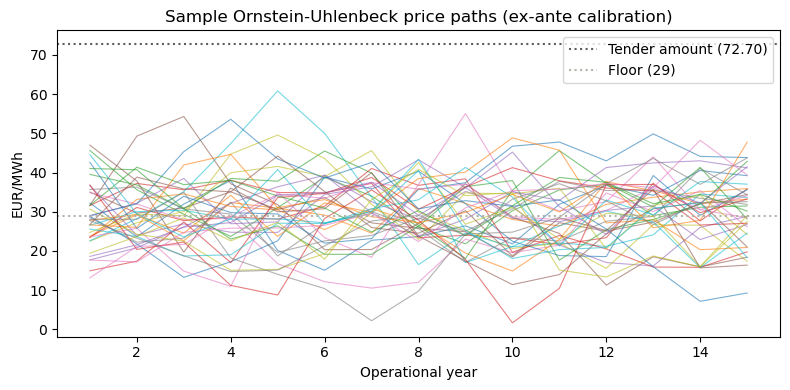

In [42]:
def simulate_ou_path(mu, theta, sigma, start_price, n_years, rng):
    """Discrete-time OU process, annual steps (dt=1)."""
    path = np.empty(n_years)
    p = start_price
    for t in range(n_years):
        p = p + theta * (mu - p) * 1.0 + sigma * rng.standard_normal()
        p = max(p, 0.0)  # price floor at zero
        path[t] = p
    return path

# Quick look: a handful of sample ex-ante paths
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(40):
    path = simulate_ou_path(ou_exante["mu"], ou_exante["theta"], ou_exante["sigma"],
                             assumptions["exante_price"], 15, rng)
    ax.plot(range(1, 16), path, linewidth=0.8, alpha=0.6)
ax.axhline(assumptions["tender"], color="#5F5E5A", linestyle=":", label="Tender amount (72.70)")
ax.axhline(assumptions["floor"], color="#B4B2A9", linestyle=":", label="Floor (29)")
ax.set_xlabel("Operational year"); ax.set_ylabel("EUR/MWh")
ax.set_title("Sample Ornstein-Uhlenbeck price paths (ex-ante calibration)")
ax.legend()
plt.tight_layout()
plt.show()


None of the sample paths come close to the tender amount. That is expected, not a limitation.
The stationary standard deviation implied by this calibration is about 8.7 EUR/MWh, so the tender
amount sits nearly five standard deviations above the mean, a multi-sigma event under a historical,
pre-crisis calibration. That correctly reflects that a 2016 analyst, using only pre-crisis data,
could not have reasonably modelled the price spike that actually occurred in 2021 and 2022. Project
1's ex-post section captures that realised spike directly from actual data, rather than from this
simulation.

## 9. Monte Carlo: covenant-breach probability

For each simulation, draw one OU price path over 15 years and one capacity factor, then run the
cash flow with the fixed debt service from the base-case sizing. The loan is already sized and
closed, so these draws test whether it survives, not how big it should have been. Record the
minimum DSCR and whether it breaches the historic covenant (1.10x) in any year.

In [43]:
N_SIMS = 5_000
cf_std = 0.03

price_draws = np.array([simulate_ou_path(ou_exante["mu"], ou_exante["theta"], ou_exante["sigma"],
                                          assumptions["exante_price"], 15, rng) for _ in range(N_SIMS)])
cf_draws = np.clip(rng.normal(assumptions["cf_p50"], cf_std, N_SIMS), 0.30, 0.65)

min_dscr = np.empty(N_SIMS)
breach = np.empty(N_SIMS, dtype=bool)
for i in range(N_SIMS):
    df_sim = run_cashflow(assumptions, sizing, price_draws[i], cf=cf_draws[i], simplified_tax=True)
    dscr_path = df_sim.loc[1:15, "dscr"]
    min_dscr[i] = dscr_path.min()
    breach[i] = (dscr_path < assumptions["dscr_historic"]).any()

print(f"Simulations:              {N_SIMS:,}")
print(f"Mean of min DSCR:         {min_dscr.mean():.2f}")
print(f"5th percentile min DSCR:  {np.percentile(min_dscr, 5):.2f}")
print(f"P(covenant breach, any yr, DSCR<{assumptions['dscr_historic']}x): {breach.mean():.1%}")
print(f"P(lock-up trips, DSCR<{assumptions['dscr_lockup']}x, any yr):     {(min_dscr < assumptions['dscr_lockup']).mean():.1%}")


Simulations:              5,000
Mean of min DSCR:         1.45
5th percentile min DSCR:  1.11
P(covenant breach, any yr, DSCR<1.1x): 4.4%
P(lock-up trips, DSCR<1.2x, any yr):     10.9%


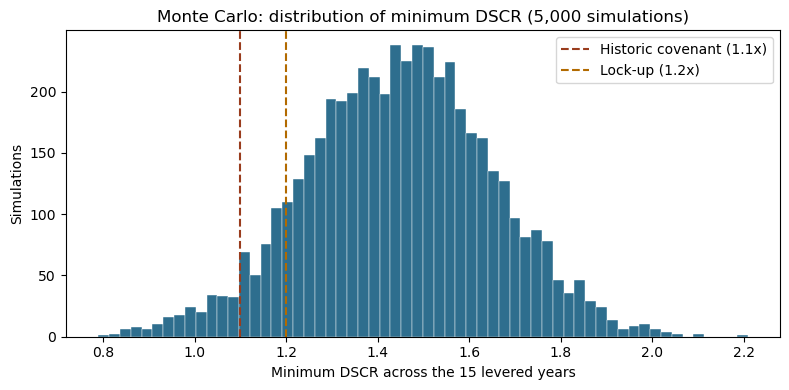

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(min_dscr, bins=60, color="#2E6E8E", edgecolor="white", linewidth=0.3)
ax.axvline(assumptions["dscr_historic"], color="#993C1D", linestyle="--", label=f"Historic covenant ({assumptions['dscr_historic']}x)")
ax.axvline(assumptions["dscr_lockup"], color="#B26A00", linestyle="--", label=f"Lock-up ({assumptions['dscr_lockup']}x)")
ax.set_xlabel("Minimum DSCR across the 15 levered years")
ax.set_ylabel("Simulations")
ax.set_title(f"Monte Carlo: distribution of minimum DSCR ({N_SIMS:,} simulations)")
ax.legend()
plt.tight_layout()
plt.show()


**Reading**: the facility was sized conservatively, LLCR-bound, well below what the DSCR test
alone would have allowed, so the covenant-breach probability should be low even with year-to-year
price variation. This is consistent with the deterministic stress tests in section 6, which all
cleared the lock-up threshold. If the breach probability had come out meaningfully higher than
those stress tests suggested, that would signal the OU volatility assumption doing more work than
the fixed shock-based scenarios captured, and would be worth flagging explicitly.

## 10. Sensitivity dashboard: where does the structure actually break?

A single Monte Carlo breach probability tells you how often things go wrong, not which combination
of shocks causes it. This section maps minimum DSCR across a grid of price and wind-resource
shocks, so the failure boundary is visible directly. It also lets you test how restructuring the
deal changes that boundary, by actually rerunning the debt sizing rather than just moving a line.

A deliberate correction to the original idea: a 3D surface looks impressive but is harder to read
precisely than a 2D heatmap with a clear contour line, and for a credit committee legibility beats
novelty. The red zone below is labelled for what it actually means: DSCR below 1.0x means the DSRA
reserve gets drawn down that year, not automatic default. Default only follows if the reserve
itself runs out. A DSRA-size slider was left out deliberately, since DSRA size affects how many
consecutive bad years the structure can absorb, not the single-year DSCR shown here, so a slider
that changed nothing on this chart would be misleading rather than illustrative.

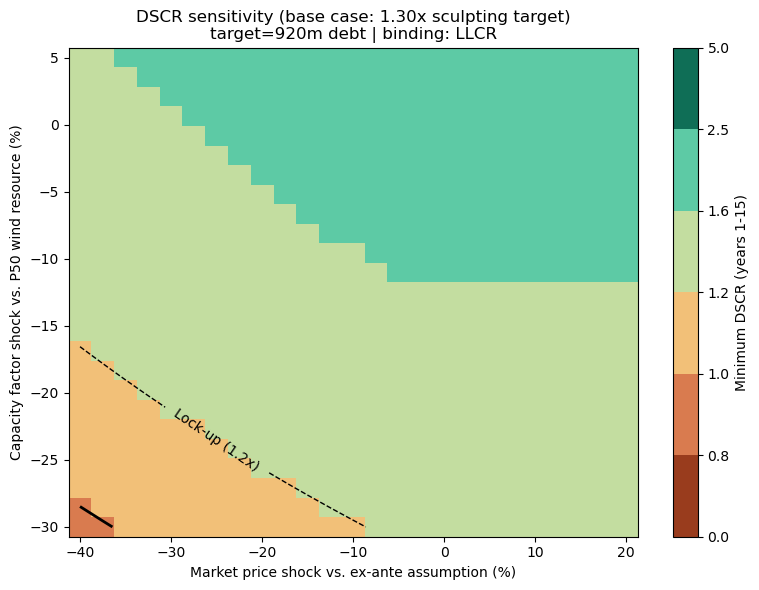

In [45]:
import matplotlib.colors as mcolors

def compute_dscr_grid(dscr_target=1.30, degradation=0.0, llcr_min=None, n=25):
    """Recomputes debt sizing at the given target/LLCR minimum, then grids minimum DSCR (yrs 1-15)
    over flat price and capacity-factor shocks around the ex-ante / P50 base case."""
    a = dict(assumptions)
    a["dscr_target"] = dscr_target
    if llcr_min is not None:
        a["llcr_min"] = llcr_min
    s = size_debt(a, degradation=degradation)

    price_shocks = np.linspace(-0.40, 0.20, n)   # -40% to +20% vs. ex-ante price (30)
    cf_shocks = np.linspace(-0.30, 0.05, n)       # -30% to +5% vs. P50 capacity factor

    grid = np.zeros((len(cf_shocks), len(price_shocks)))
    for i, cf_shock in enumerate(cf_shocks):
        cf = a["cf_p50"] * (1 + cf_shock)
        for j, p_shock in enumerate(price_shocks):
            price_path = np.full(15, a["exante_price"] * (1 + p_shock))
            df = run_cashflow(a, s, price_path, degradation=degradation, cf=cf, simplified_tax=True)
            grid[i, j] = df.loc[1:15, "dscr"].min()
    return price_shocks, cf_shocks, grid, s

# Shared colour scale: red = reserve draw-down territory, amber = below lock-up, green = healthy
LEVELS = [0, 0.8, 1.0, assumptions["dscr_lockup"], 1.6, 2.5, 5.0]
COLORS = ["#993C1D", "#D97B4F", "#F2C078", "#C3DDA0", "#5DCAA5", "#0F6E56"]
CMAP = mcolors.ListedColormap(COLORS)
NORM = mcolors.BoundaryNorm(LEVELS, CMAP.N)

def plot_dscr_grid(price_shocks, cf_shocks, grid, s, title_extra=""):
    fig, ax = plt.subplots(figsize=(8, 6))
    X, Y = np.meshgrid(price_shocks * 100, cf_shocks * 100)
    pcm = ax.pcolormesh(X, Y, grid, cmap=CMAP, norm=NORM, shading="auto")
    fig.colorbar(pcm, ax=ax, label="Minimum DSCR (years 1-15)")
    cs1 = ax.contour(X, Y, grid, levels=[1.0], colors="black", linewidths=2)
    ax.clabel(cs1, fmt={1.0: "DSCR = 1.0x (reserve drawn down)"})
    cs2 = ax.contour(X, Y, grid, levels=[assumptions["dscr_lockup"]], colors="black",
                      linewidths=1, linestyles="dashed")
    ax.clabel(cs2, fmt={assumptions["dscr_lockup"]: f"Lock-up ({assumptions['dscr_lockup']}x)"})
    ax.set_xlabel("Market price shock vs. ex-ante assumption (%)")
    ax.set_ylabel("Capacity factor shock vs. P50 wind resource (%)")
    ax.set_title(f"DSCR sensitivity {title_extra}\n"
                 f"target={s['actual_debt']/1e6:,.0f}m debt | binding: {s['binding']}")
    plt.tight_layout()
    plt.show()

# Static reference chart: base case (dscr_target=1.30, no degradation)
ps, cfs, grid_base, s_base = compute_dscr_grid(dscr_target=1.30, degradation=0.0)
plot_dscr_grid(ps, cfs, grid_base, s_base, title_extra="(base case: 1.30x sculpting target)")


**Reading**: the black solid contour is the boundary that actually matters for solvency, where
DSCR drops below 1.0x and draws on the reserve. The dashed contour is where the lock-up test would
first block equity distributions, well before that. The green area covering most of the grid is
consistent with the earlier finding that this facility was conservatively sized on LLCR. The
combined P90 and price shock stress test point sits close to, but still outside, the red zone.

Target 1.30x -> actual debt EUR 920m, binding: LLCR
Target 1.45x -> actual debt EUR 920m, binding: LLCR
Red-zone area (DSCR<1.0), 1.30x target: 0.5% of grid
Red-zone area (DSCR<1.0), 1.45x target: 0.5% of grid


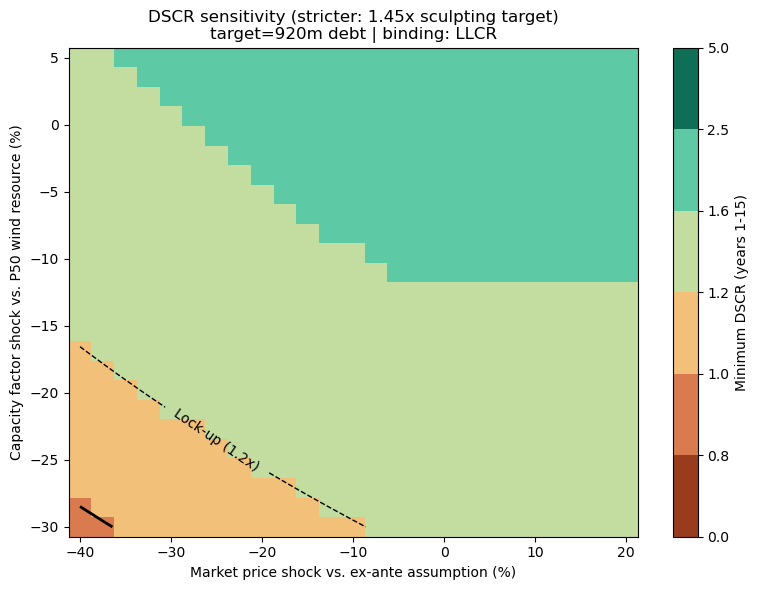

In [46]:
# Structuring comparison: a stricter DSCR sculpting target at financial close
ps2, cfs2, grid_strict, s_strict = compute_dscr_grid(dscr_target=1.45, degradation=0.0)

print(f"Target 1.30x -> actual debt EUR {s_base['actual_debt']/1e6:,.0f}m, binding: {s_base['binding']}")
print(f"Target 1.45x -> actual debt EUR {s_strict['actual_debt']/1e6:,.0f}m, binding: {s_strict['binding']}")
print(f"Red-zone area (DSCR<1.0), 1.30x target: {(grid_base < 1.0).mean():.1%} of grid")
print(f"Red-zone area (DSCR<1.0), 1.45x target: {(grid_strict < 1.0).mean():.1%} of grid")

plot_dscr_grid(ps2, cfs2, grid_strict, s_strict, title_extra="(stricter: 1.45x sculpting target)")


**Reading, and a correction to the pitch this section was built on**: raising the sculpting
target from 1.30x to 1.45x changes nothing. Same debt amount, same red zone. That is not a bug. It
is the direct consequence of section 3's finding that LLCR, not DSCR sculpting, is the binding
constraint for this facility. The DSCR target only tightens the DSCR-sculpted capacity test, which
was already well above the LLCR-implied capacity at 1.30x. Pushing it down further with a stricter
target still leaves it above LLCR, so LLCR keeps binding and nothing moves.

This is a more useful finding than the "turn the dial, watch it shrink" story a dashboard like this
is often pitched with. A credit analyst negotiating covenants first needs to know which test is
actually load-bearing, or they negotiate a lever that does nothing. The cell below flexes the lever
that does bind here, the LLCR minimum, to show the contrast directly.

LLCR min 1.40x -> actual debt EUR 920m
LLCR min 1.25x -> actual debt EUR 1,030m
Red-zone area (DSCR<1.0), LLCR min 1.40x: 0.5% of grid
Red-zone area (DSCR<1.0), LLCR min 1.25x: 5.0% of grid


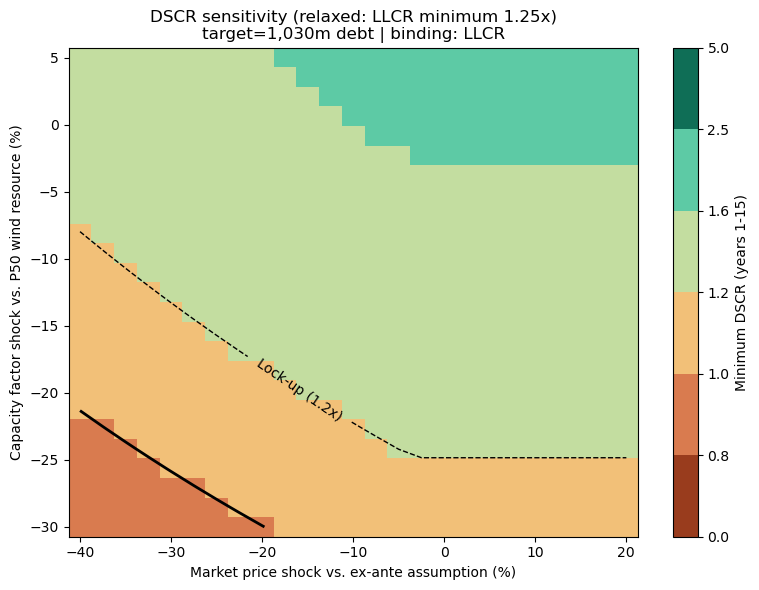

In [47]:
# The lever that actually binds this deal: the LLCR minimum, not the DSCR target
ps4, cfs4, grid_relaxed, s_relaxed = compute_dscr_grid(llcr_min=1.25)

print(f"LLCR min 1.40x -> actual debt EUR {sizing['actual_debt']/1e6:,.0f}m")
print(f"LLCR min 1.25x -> actual debt EUR {s_relaxed['actual_debt']/1e6:,.0f}m")
print(f"Red-zone area (DSCR<1.0), LLCR min 1.40x: {(grid_base < 1.0).mean():.1%} of grid")
print(f"Red-zone area (DSCR<1.0), LLCR min 1.25x: {(grid_relaxed < 1.0).mean():.1%} of grid")

plot_dscr_grid(ps4, cfs4, grid_relaxed, s_relaxed, title_extra="(relaxed: LLCR minimum 1.25x)")


**Reading**: relaxing the LLCR minimum does increase the loan size and does widen the red zone,
because this is the constraint that was actually binding. The lesson generalises beyond this one
deal: before proposing to tighten a covenant to reduce risk, or relax one to increase leverage,
check which test is binding first. Negotiating a non-binding covenant is a wasted negotiation.

### Live version, run this yourself in Jupyter

The static charts above use fixed parameters. The cell below adds sliders for the DSCR sculpting
target, the LLCR minimum, and the degradation assumption, recomputing the grid on every change.
This only renders as an interactive widget in a live Jupyter session. A static export, such as a
PDF or this notebook viewed non-interactively, will just show a placeholder for the widget, not
the chart itself.

In [49]:
import ipywidgets as widgets
from IPython.display import display

def _interactive_plot(dscr_target, llcr_min, degradation_pct):
    ps_i, cfs_i, grid_i, s_i = compute_dscr_grid(dscr_target=dscr_target, llcr_min=llcr_min,
                                                   degradation=degradation_pct / 100)
    plot_dscr_grid(ps_i, cfs_i, grid_i, s_i,
                    title_extra=f"(DSCR target={dscr_target:.2f}x, LLCR min={llcr_min:.2f}x, "
                                 f"degradation={degradation_pct:.1f}%/yr)")

widgets.interact(
    _interactive_plot,
    dscr_target=widgets.FloatSlider(min=1.10, max=1.50, step=0.05, value=1.30, description="DSCR target"),
    llcr_min=widgets.FloatSlider(min=1.10, max=1.60, step=0.05, value=1.40, description="LLCR min"),
    degradation_pct=widgets.FloatSlider(min=0.0, max=2.0, step=0.25, value=0.0, description="Degradation %/yr"),
);


interactive(children=(FloatSlider(value=1.3, description='DSCR target', max=1.5, min=1.1, step=0.05), FloatSli…